In [2]:
import torch
from torch import nn
from collections import Counter
import random
import numpy as np
import torch.optim as optim

In [3]:
# read text8
with open('./text8','r') as f:
    characters = f.read()
print(characters[:100])
print(len(characters))


 anarchism originated as a term of abuse first used against early working class radicals including t
100000000


In [4]:
# trim the corpus: remove the words < 5 times
# get words
words = characters.split()

# count the occurance of each unique word
# the result is stored in a dict: word_counts, key=word, value=count
# order: from largest to smallest
word_counts = Counter(words)

# delete rare words with count less or equal to 5
trimmed_words = [word for word in words if word_counts[word] > 5]

print(trimmed_words[:20]) # first 20 words
print(len(trimmed_words)) # total words
print(len(set(trimmed_words)))  # unique words, vocab size

['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including', 'the', 'diggers', 'of', 'the', 'english']
16680599
63641


In [5]:
# create vocabuary look up tables: word-to-int, int-to-word

def build_vocab(words):
    """
    Create two vocabuary dictionaries:
    ---vocab_to_int: key=word, value=index
    ---int_to_vocab: key=index, value=word
    input: corpus (a list of words)
    return: Two dictionaries, vocab_to_int, int_to_vocab
    """
    # word_counts is a dictionary, key=word, and value=counts
    word_counts = Counter(words)
    # sorted_vocab is a list vocab words from most to leas frequent
    sorted_vocab = sorted(word_counts, key=word_counts.get, reverse=True)
    # create int_to_vocab dictionary: key=index, value=word
    int_to_vocab = {ii: word for ii, word in enumerate(sorted_vocab)}
    # create vocab_to_int dictionary: key=word, value=index
    vocab_to_int = {word: ii for ii, word in int_to_vocab.items()}

    return vocab_to_int, int_to_vocab


In [6]:
# create vocab look-up tables:
# vocab_to_int: key=word, value=index
# int_to_vocab: key=index, value=word
# from most frequent to least frequent
vocab_to_int, int_to_vocab = build_vocab(trimmed_words)

# generate the list of the trimmed words in a format of index
int_words = [vocab_to_int[word] for word in trimmed_words]

print(trimmed_words[:20])
print(int_words[:20])
print(len(int_words))

['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including', 'the', 'diggers', 'of', 'the', 'english']
[5233, 3080, 11, 5, 194, 1, 3133, 45, 58, 155, 127, 741, 476, 10571, 133, 0, 27349, 1, 0, 102]
16680599


In [7]:
# subsampling: randomly drop high frequent words with certain probabilities
def subsampling(int_words):
  threshold = 1e-5
  word_counts = Counter(int_words) # count for each unique word
  total_count = len(int_words) # total number of words
  # calculate the frequency of each word
  word_freqs = {word: count/total_count for word, count in word_counts.items()}
  # calculate the probability of drop for each word
  p_drop = {word: 1 - np.sqrt(threshold/word_freqs[word]) for word in word_counts}
  # discard some frequent words, according to the subsampling equation
  train_words = [word for word in int_words if random.random() < (1 - p_drop[word])]

  return train_words

In [8]:
# generate training  corpus (words) by subsampling
train_words = subsampling(int_words)
# words after random drop of high frequent words
print(len(train_words))
print(train_words[:20])

4626672
[5233, 3080, 3133, 741, 10571, 27349, 102, 854, 15067, 58112, 10712, 2731, 708, 53, 97, 7088, 1052, 44611, 2877, 2621]


In [10]:
# generate a list of target (context) words, with a random length.
# given a list of words, center word (idx) and window_size

def get_target(words, idx, window_size=5):
    ''' Get a context in a window around a center word (idx). '''

    R = np.random.randint(1, window_size+1)
    start = idx - R if (idx - R) > 0 else 0
    stop = idx + R
    target_words = words[start:idx] + words[idx+1:stop+1]

    return list(target_words)

###---------test your code!
# run following codes to see the random length of target
int_text = [i for i in range(20)]
print('Input: ', int_text)
idx=5 # word index of interest

target = get_target(int_text, idx=idx, window_size=5)
print('Target: ', target)
# you should get some inputs around the idx

Input:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Target:  [1, 2, 3, 4, 6, 7, 8, 9]


In [11]:

def generate_batches(words, batch_size, window_size=5):
    ''' Create a generator of word batches as a tuple (x, y)
    (x,y) a batch of input-target pairs
    '''

    n_batches = len(words)//batch_size

    # consider only full batches
    words = words[:n_batches*batch_size]

    for idx in range(0, len(words), batch_size):
        x, y = [], []
        batch = words[idx:idx+batch_size]
        for ii in range(len(batch)):
            batch_x = batch[ii] # center word
            batch_y = get_target(batch, ii, window_size) # context of batch_x
            y.extend(batch_y) # added to the batch
            x.extend([batch_x]*len(batch_y))
            #duplicate the center word for each context word
        yield x, y

In [13]:
###--- test generate_batches(words, batch_size, window_size=5)

int_text = [i for i in range(100)]
for x,y in generate_batches(int_text, batch_size=10, window_size=5):
    print('x\n', x)
    print('y\n', y)

x
 [0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 6, 6, 7, 7, 7, 7, 7, 7, 7, 8, 8, 9, 9]
y
 [1, 2, 0, 2, 3, 4, 5, 6, 1, 3, 1, 2, 4, 5, 1, 2, 3, 5, 6, 7, 2, 3, 4, 6, 7, 8, 5, 7, 2, 3, 4, 5, 6, 8, 9, 7, 9, 7, 8]
x
 [10, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 13, 13, 14, 14, 14, 14, 15, 15, 16, 16, 16, 16, 17, 17, 17, 17, 18, 18, 18, 18, 19, 19]
y
 [11, 10, 12, 13, 14, 10, 11, 13, 14, 15, 16, 17, 12, 14, 12, 13, 15, 16, 14, 16, 14, 15, 17, 18, 15, 16, 18, 19, 15, 16, 17, 19, 17, 18]
x
 [20, 20, 20, 21, 21, 22, 22, 22, 22, 22, 22, 23, 23, 23, 23, 23, 23, 24, 24, 25, 25, 25, 25, 25, 25, 26, 26, 26, 26, 26, 26, 26, 27, 27, 27, 27, 27, 27, 27, 28, 28, 28, 28, 28, 28, 29, 29, 29, 29, 29]
y
 [21, 22, 23, 20, 22, 20, 21, 23, 24, 25, 26, 20, 21, 22, 24, 25, 26, 23, 25, 22, 23, 24, 26, 27, 28, 22, 23, 24, 25, 27, 28, 29, 22, 23, 24, 25, 26, 28, 29, 23, 24, 25, 26, 27, 29, 24, 25, 26, 27, 28]
x
 [30, 31, 31, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33, 33, 33

In [14]:
def cosine_similarity(embedding, valid_words, device='cpu'):
  '''
  compute the similaritiess between valid_words and all words in vocab
  embedding: a embedding model
  valid_words: a list of words
  device: cpu or gpu
  return: a tensor of similarities, shape=(len(valid_words), len(vocab))
  '''
  embed_vectors = embedding.weight
  magnitudes = embed_vectors.pow(2).sum(dim=1).sqrt().unsqueeze(0)
  valid_examples = torch.LongTensor([vocab_to_int[word] for word in valid_words]).to(device)
  valid_vectors = embedding(valid_examples)
  similarities = torch.mm(valid_vectors, embed_vectors.t())/magnitudes
  return similarities

In [15]:
class SkipGram(nn.Module):
    def __init__(self, n_vocab, dim_embed):
        super().__init__()

        self.embed = nn.Embedding(n_vocab, dim_embed)
        self.output = nn.Linear(dim_embed, n_vocab)
        self.log_softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = self.embed(x)
        scores = self.output(x)
        log_ps = self.log_softmax(scores)

        return log_ps

In [35]:
# specify device as GPU or CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'

embedding_dim=300 # you can use a differen one

model = SkipGram(len(vocab_to_int), embedding_dim).to(device)
criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.004)

print_every = 1000
steps = 0
epochs = 5
losses = []

# specify the validation words
valid_words = ['http', 'often', 'six', 'institute']

# testing the intial model, find the closet words for valid_words
print("Before training:")
valid_similarities = cosine_similarity(model.embed, valid_words, device=device)
__, closest_idxs = valid_similarities.topk(6) # topk highest similarities

for i, valid_word in enumerate(valid_words):
    closest_words = [int_to_vocab[idx.item()] for idx in closest_idxs[i]][1:]
    print(valid_word + " : " + ', '.join(closest_words))

# train for some number of epochs
for e in range(epochs):
  steps = 0
  # get input and target batches
  print("Epoch: {}/{}...".format(e+1, epochs))
  for inputs, targets in generate_batches(train_words, 512):
    steps += 1
    inputs, targets = torch.LongTensor(inputs), torch.LongTensor(targets)
    inputs, targets = inputs.to(device), targets.to(device)

    log_ps = model(inputs)
    loss = criterion(log_ps, targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if steps % print_every == 0:  # monintor progress within an epoch
          print("Epoch: {}/{}...".format(e+1, epochs),
                "Step: {}/{}...".format(steps, len(train_words)//512))
            # getting examples and similarities
          '''
          valid_similarities = cosine_similarity(model.embed, valid_words, device=device)
          __, closest_idxs = valid_similarities.topk(6) # topk highest similarities

          for i, valid_word in enumerate(valid_words):
            closest_words = [int_to_vocab[idx.item()] for idx in closest_idxs[i]][1:]
            print(valid_word + " : " + ', '.join(closest_words))
          '''
          print("loss", loss.item())
          losses.append(loss.item())

  # test after epoch e training
  print("After epoch: {}/{}... validation...".format(e+1, epochs))
  valid_similarities = cosine_similarity(model.embed, valid_words, device=device)
  __, closest_idxs = valid_similarities.topk(6)
  # return topk highest similarities and their index
  # closest_idxs shape: (len(valid_words), 6)

  for i, valid_word in enumerate(valid_words):
    closest_words = [int_to_vocab[idx.item()] for idx in closest_idxs[i]][1:]
    print(valid_word + " : " + ', '.join(closest_words))



Before training:
http : armalite, rockefeller, quotient, hooves, clipperton
often : complicate, ritualistic, hayashi, specials, recommends
six : baetica, hoche, imovie, packers, synergy
institute : rulebook, figuratively, petits, nomination, obstructive
Epoch: 1/5...
Epoch: 1/5... Step: 1000/9036...
loss 11.09475040435791
Epoch: 1/5... Step: 2000/9036...
loss 10.974963188171387
Epoch: 1/5... Step: 3000/9036...
loss 10.824450492858887
Epoch: 1/5... Step: 4000/9036...
loss 9.974924087524414
Epoch: 1/5... Step: 5000/9036...
loss 9.853986740112305
Epoch: 1/5... Step: 6000/9036...
loss 10.343403816223145
Epoch: 1/5... Step: 7000/9036...
loss 10.313309669494629
Epoch: 1/5... Step: 8000/9036...
loss 10.5675630569458
Epoch: 1/5... Step: 9000/9036...
loss 10.520866394042969
After epoch: 1/5... validation...
http : www, links, htm, org, com
often : bizkit, ritualistic, hayashi, leith, pillows
six : zero, eight, one, seven, three
institute : research, engineering, foresee, journals, bulletin
Epoc

In [36]:
 # getting examples and similarities
valid_words = ['china', 'red', 'six', 'institute', 'student']
valid_similarities = cosine_similarity(model.embed, valid_words, device=device)
__, closest_idxs = valid_similarities.topk(6) # topk highest similarities

for i, valid_word in enumerate(valid_words):
    closest_words = [int_to_vocab[idx.item()] for idx in closest_idxs[i]][1:]

    print(valid_word + " : " + ', '.join(closest_words))

china : chinese, beijing, taiwan, prc, zedong
red : yellow, green, white, blue, crescent
six : one, three, four, five, zero
institute : university, mit, research, technology, universities
student : students, school, faculty, university, teachers


In [42]:
print(valid_similarities.shape)
print(valid_similarities)
print(closest_idxs.shape)
print(closest_idxs)
print(int_to_vocab[15])

torch.Size([5, 63641])
tensor([[ 0.1412,  0.2960,  0.2099,  ..., -0.0159,  0.3601, -0.1322],
        [ 0.2639,  0.1499,  0.4195,  ..., -0.0594,  0.1725, -0.0821],
        [ 0.4984,  0.7620,  0.6244,  ..., -0.1336,  0.0984,  0.1432],
        [ 0.1101,  0.2653,  0.5715,  ..., -0.0535, -0.3006,  0.1537],
        [-0.2962,  0.1189, -0.0940,  ..., -0.1116, -0.0068,  0.1146]],
       device='cuda:0', grad_fn=<DivBackward0>)
torch.Size([5, 6])
tensor([[  485,   471,  3881,  3559,  7505, 15143],
        [  411,  2457,   828,   395,   758,  7500],
        [   21,     3,    16,    20,    15,     7],
        [ 1023,   126,  3269,   459,   545,  2051],
        [ 1479,   918,   301,  5013,   126,  4310]], device='cuda:0')
five


In [37]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [38]:
# getting embeddings from the embedding layer of our model, by name
embeddings = model.embed.weight.to('cpu').data.numpy()

In [39]:
viz_words = 600
tsne = TSNE()
embed_tsne = tsne.fit_transform(embeddings[:viz_words, :])

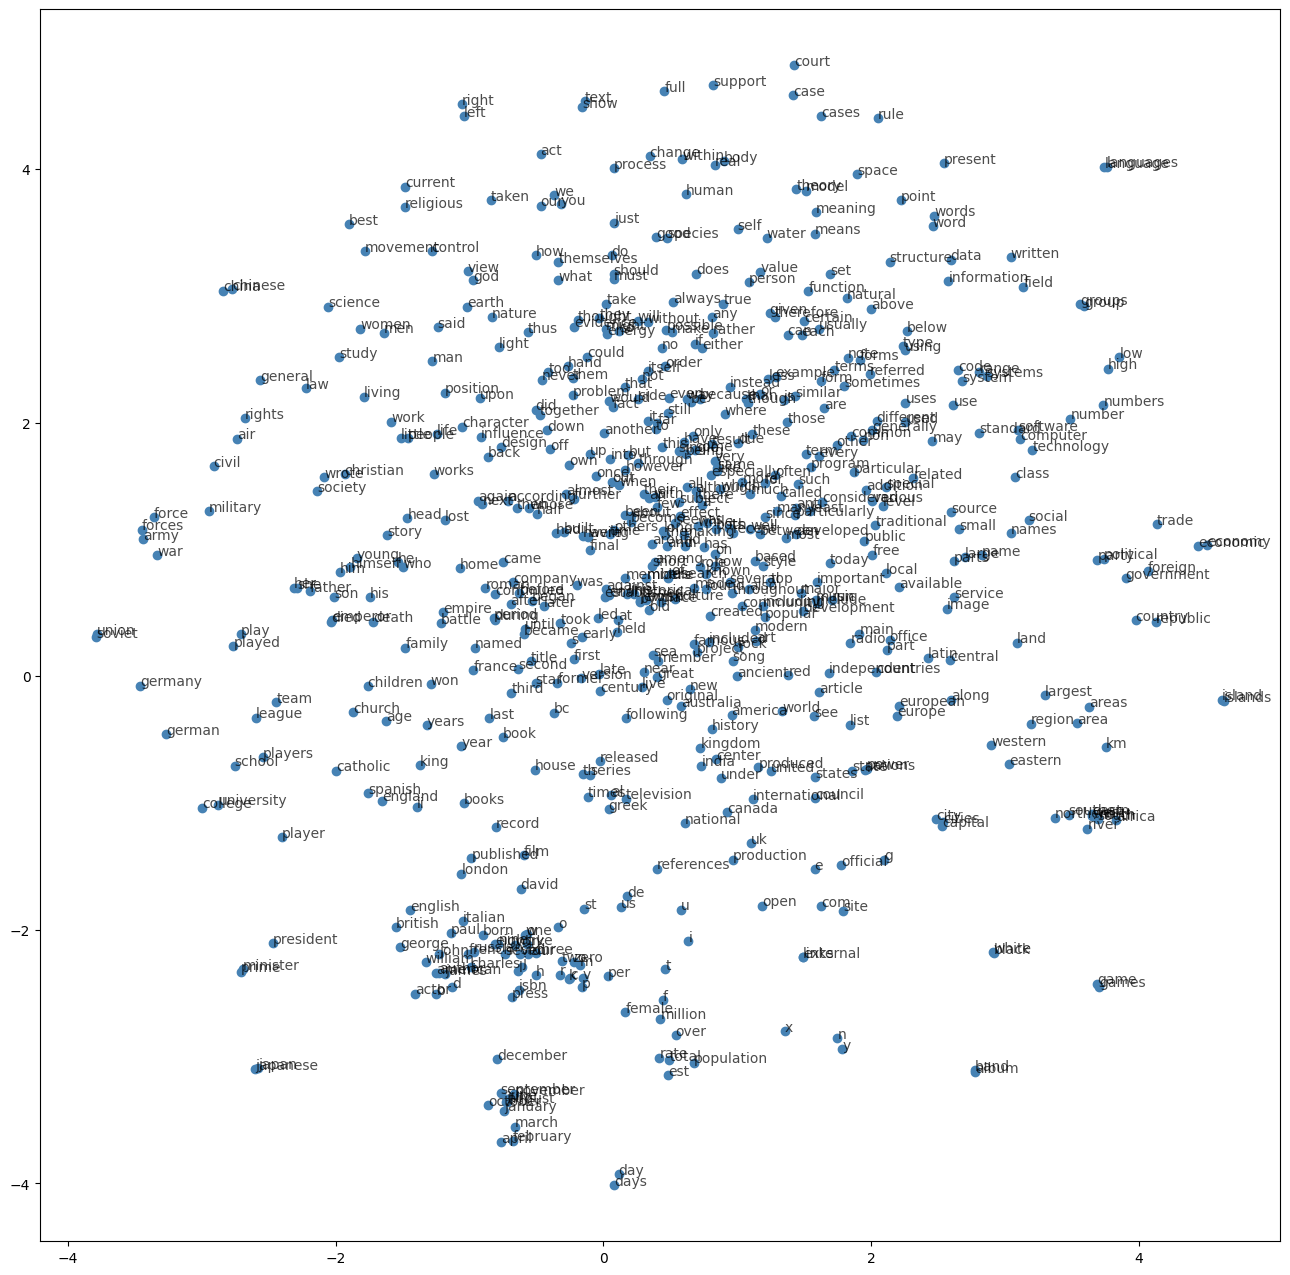

In [40]:
fig, ax = plt.subplots(figsize=(16, 16))
for idx in range(viz_words):
    plt.scatter(*embed_tsne[idx, :], color='steelblue')
    plt.annotate(int_to_vocab[idx], (embed_tsne[idx, 0], embed_tsne[idx, 1]), alpha=0.7)

In [ ]:
input1 = torch.randn(100, 128)
input2 = torch.randn(100, 128)
cos = nn.CosineSimilarity(dim=1, eps=1e-6)
output = cos(input1, input2)
print(output.shape)

torch.Size([100])
